# Stack Overflow 2024 Developer Survey — Visualizations

A few more angles on the data that weren't covered in `02_eda_and_insights.ipynb`.
The goal here was to apply several chart types (histogram, boxplot, bubble plot, pie chart,
stacked bar) to the same dataset and compare which type fits which kind of question best.


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import textwrap

pd.set_option('display.max_columns', None)

data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
df = pd.read_csv(data_url)

age_mapping = {
    'Under 18 years old': 17, '18-24 years old': 21, '25-34 years old': 29,
    '35-44 years old': 39, '45-54 years old': 49, '55-64 years old': 59,
    '65 years or older': 65, 'Prefer not to say': None
}
df['Age_numeric'] = df['Age'].map(age_mapping)

# A large share of ConvertedCompYearly is missing in the raw data. Filling it with a single
# median value (as 01_data_cleaning.ipynb does for completeness) would mean tens of thousands of
# rows carry an identical value, which distorts every distribution/comparison chart below. For
# these visualizations I only keep rows with an actually reported value.
df = df[df['ConvertedCompYearly'].notna()].copy()

## 1. The Trap in Raw Compensation Data — Multi-Currency Values

Plotting the raw `CompTotal` distribution as a histogram makes it nearly unreadable because of
extreme outliers. That's because `CompTotal` is the unconverted value in whatever currency the
respondent answered in, so the scale varies wildly depending on which country they're from.
(`ConvertedCompYearly` is the column that corrects for this by converting everything to USD.)

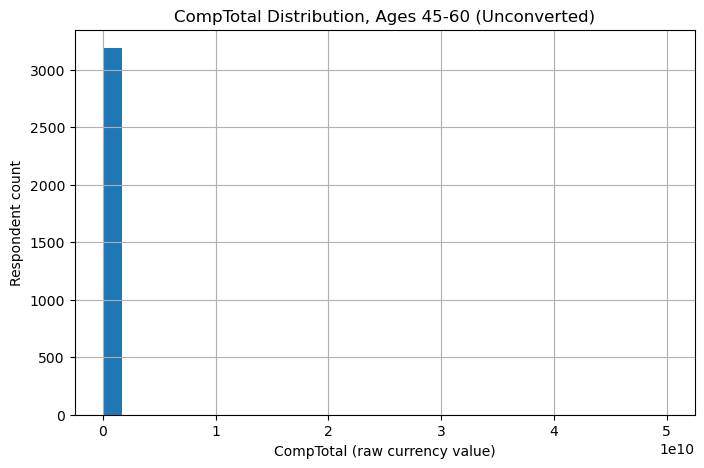

In [11]:
filtered_age = df[(df['Age_numeric'] >= 45) & (df['Age_numeric'] <= 60)]

plt.figure(figsize=(8, 5))
filtered_age['CompTotal'].hist(bins=30)
plt.title('CompTotal Distribution, Ages 45-60 (Unconverted)')
plt.xlabel('CompTotal (raw currency value)')
plt.ylabel('Respondent count')
plt.show()

# CompTotal mixes multiple currencies without conversion, so the distribution
# is heavily distorted by extreme outliers.

**Comparison**: Plotting the same idea with `ConvertedCompYearly` (USD-converted) gives a much
more interpretable distribution.

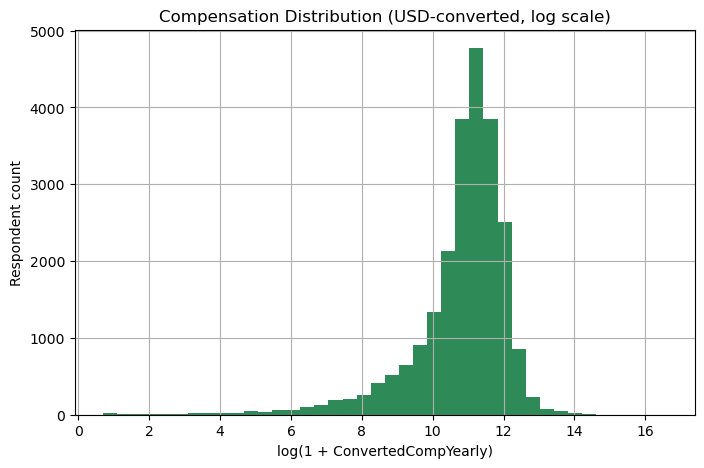

In [12]:
plt.figure(figsize=(8, 5))
np.log1p(df['ConvertedCompYearly']).hist(bins=40, color='seagreen')
plt.title('Compensation Distribution (USD-converted, log scale)')
plt.xlabel('log(1 + ConvertedCompYearly)')
plt.ylabel('Respondent count')
plt.show()

## 2. Job Satisfaction Distribution by Experience Group

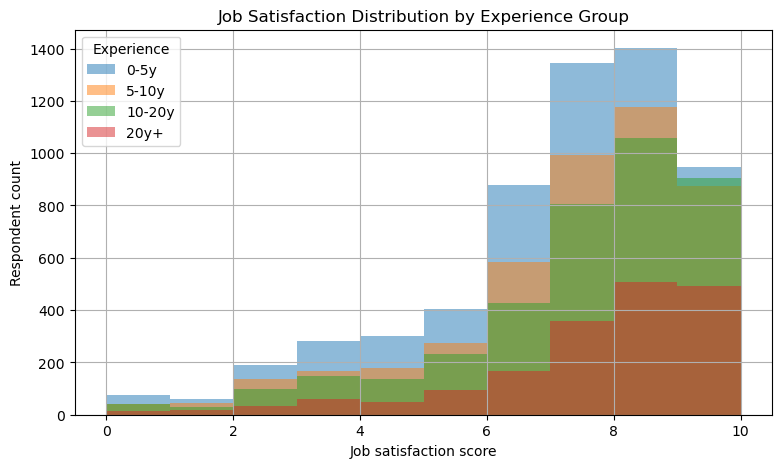

In [13]:
QUERY = df[['JobSat', 'YearsCodePro']].copy()
QUERY['YearsCodePro'] = QUERY['YearsCodePro'].astype(str).replace({
    'Less than 1 year': '0.5',
    'More than 50 years': '51'
})
QUERY['YearsCodePro'] = pd.to_numeric(QUERY['YearsCodePro'], errors='coerce')
QUERY = QUERY.dropna(subset=['JobSat'])

bins = [0, 5, 10, 20, np.inf]
labels = ['0-5y', '5-10y', '10-20y', '20y+']
QUERY['ExpGroup'] = pd.cut(QUERY['YearsCodePro'], bins=bins, labels=labels)

plt.figure(figsize=(9, 5))
for grp in labels:
    subset = QUERY[QUERY['ExpGroup'] == grp]['JobSat']
    subset.hist(bins=10, alpha=0.5, label=grp)

plt.legend(title='Experience')
plt.title('Job Satisfaction Distribution by Experience Group')
plt.xlabel('Job satisfaction score')
plt.ylabel('Respondent count')
plt.show()

## 3. Compensation by Developer Type (Top 5)

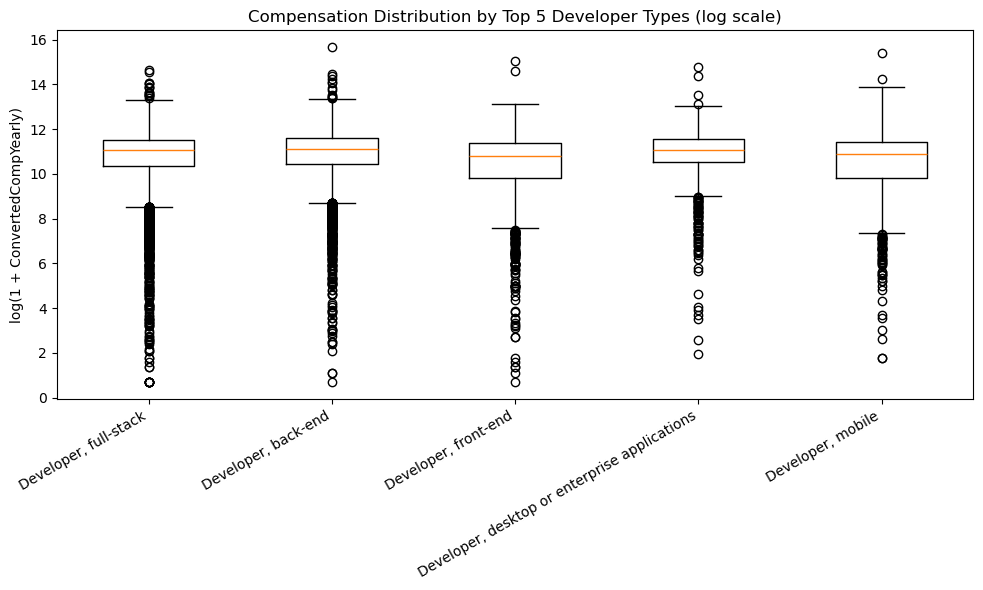

In [14]:
dev = df[['ConvertedCompYearly', 'DevType']].copy()
top5_dev = dev['DevType'].str.split(';').explode().str.strip().value_counts().head(5).index

data, labels = [], []
for dev_type in top5_dev:
    subset = np.log1p(dev[dev['DevType'].str.contains(dev_type, na=False)]['ConvertedCompYearly'].dropna())
    data.append(subset)
    labels.append(dev_type)

plt.figure(figsize=(10, 6))
plt.boxplot(data, tick_labels=labels)
plt.title('Compensation Distribution by Top 5 Developer Types (log scale)')
plt.xticks(rotation=30, ha='right')
plt.ylabel('log(1 + ConvertedCompYearly)')
plt.tight_layout()
plt.show()

# If the boxes are spread wide rather than clustered tightly, that suggests a lot of
# variation within a single developer type - likely because students, job seekers, and
# senior professionals all get grouped under the same role label.

## 4. Top 5 Databases Developers Want to Learn (Composition)

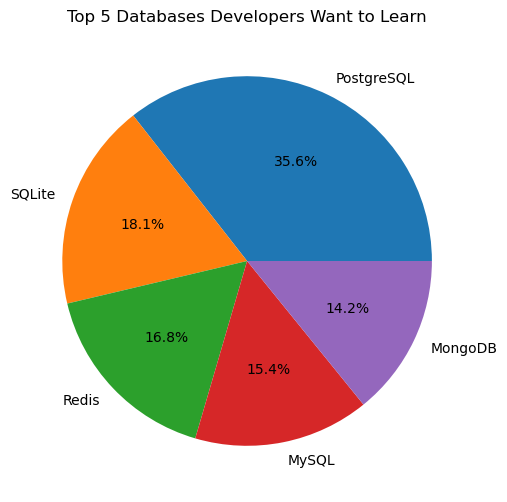

In [15]:
top5_db = df['DatabaseWantToWorkWith'].str.split(';').explode().str.strip().value_counts().head(5)

plt.figure(figsize=(6, 6))
top5_db.plot(kind='pie', autopct='%1.1f%%')
plt.title('Top 5 Databases Developers Want to Learn')
plt.ylabel('')
plt.show()

## 5. Compensation × Job Satisfaction × Age (Bubble Plot)

Combining three variables into one chart, with bubble size representing age.

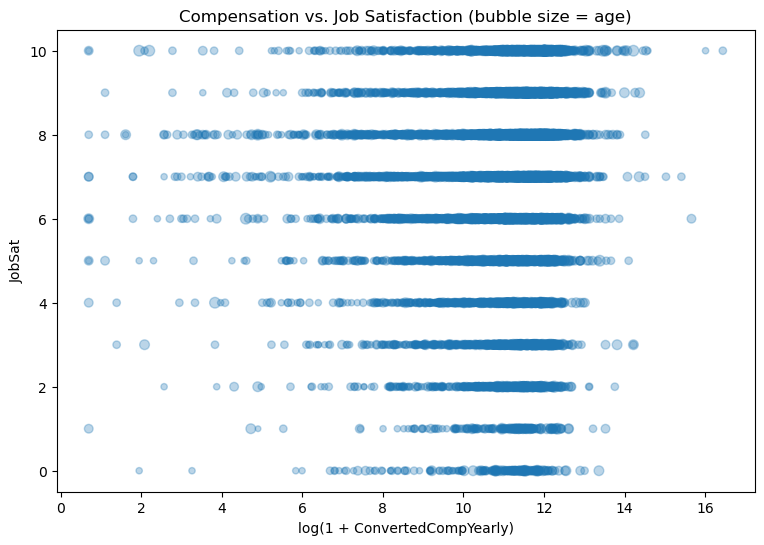

In [16]:
plt.figure(figsize=(9, 6))
plt.scatter(np.log1p(df['ConvertedCompYearly']),
            df['JobSat'],
            s=df['Age_numeric'].fillna(df['Age_numeric'].mean()),
            alpha=0.3)
plt.xlabel('log(1 + ConvertedCompYearly)')
plt.ylabel('JobSat')
plt.title('Compensation vs. Job Satisfaction (bubble size = age)')
plt.show()

# The points are scattered fairly evenly regardless of bubble size (age), which suggests
# there isn't a strong three-way relationship between compensation, satisfaction, and age.

## 6. Employment Type Composition by Job Satisfaction Score

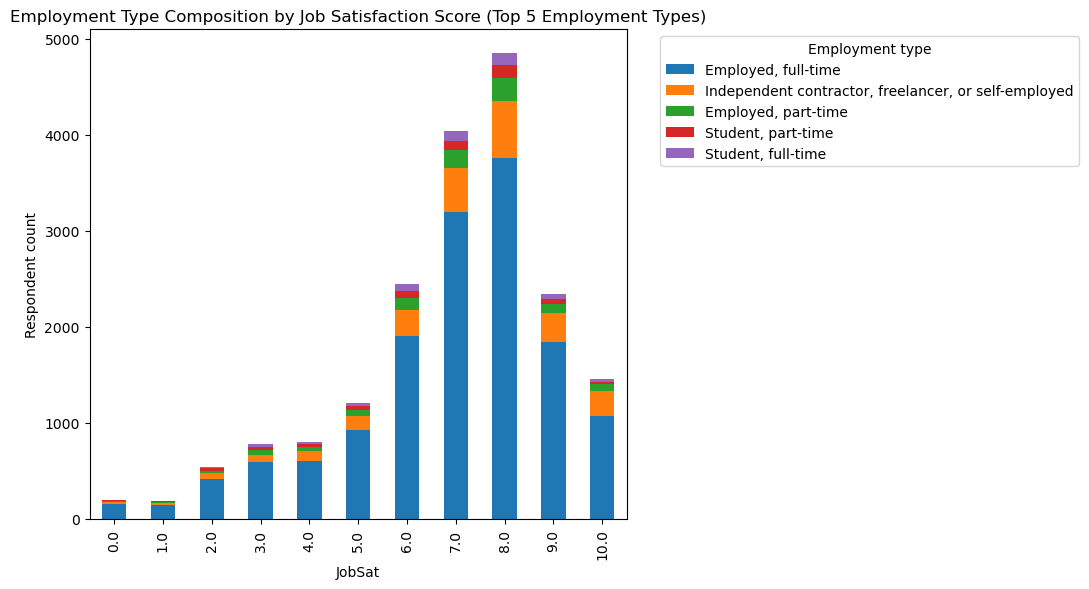

In [17]:
emp_exploded = df[['Employment', 'JobSat']].copy()
emp_exploded['Employment'] = emp_exploded['Employment'].str.split(';')
emp_exploded = emp_exploded.explode('Employment')
emp_exploded['Employment'] = emp_exploded['Employment'].str.strip()

emp_sat = emp_exploded.groupby(['JobSat', 'Employment']).size().unstack(fill_value=0)
top_emp_cols = emp_sat.sum().sort_values(ascending=False).head(5).index
emp_sat = emp_sat[top_emp_cols]

emp_sat.plot(kind='bar', stacked=True, figsize=(11, 6))
plt.title('Employment Type Composition by Job Satisfaction Score (Top 5 Employment Types)')
plt.xlabel('JobSat')
plt.ylabel('Respondent count')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Employment type')
plt.tight_layout()
plt.show()

## 7. Respondent Distribution by Country (Top 15)

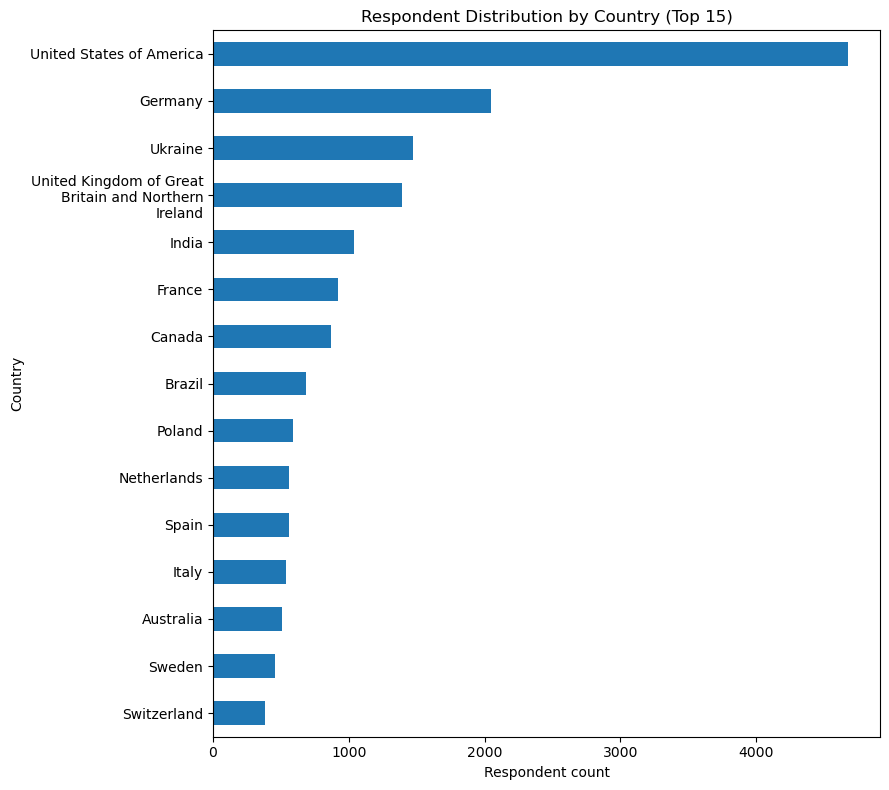

In [18]:
country_dist = df['Country'].value_counts().head(15)
wrapped_labels = [textwrap.fill(label, width=25) for label in country_dist.index]

plt.figure(figsize=(9, 8))
ax = country_dist.plot(kind='barh')
ax.set_yticklabels(wrapped_labels)
ax.invert_yaxis()
plt.title('Respondent Distribution by Country (Top 15)')
plt.xlabel('Respondent count')
plt.tight_layout()
plt.show()

## Summary

Comparing chart types across this dataset surfaced a few takeaways:

- **Histograms** are great for a single variable's distribution, but applying one to an unconverted
  column like `CompTotal` distorts the picture because of extreme outliers. Converted or log-scaled
  values matter here.
- **Boxplots** are good for comparing groups, but if the composition within a group is heterogeneous
  (e.g. students and senior professionals lumped under the same role), the spread can be misleading.
- **Bubble plots** can show three variables at once, but when the underlying relationship is weak,
  the extra visual complexity doesn't necessarily add much.
- **Pie charts / stacked bars** are intuitive for showing composition, but once the number of categories
  grows (e.g. 10+ employment types), readability drops fast — narrowing down to the top N is almost
  always necessary.

The full analysis and overall findings for this project are summarized in the [README](./README.md).
